<p class="task" id="1"></p>

1\. Обучите агента для игры в блэкджек (окружение `Blackjack-v1`), используя алгоритм Q-learning. Для создания таблицы Q-функции выясните размеры пространства состояния игры и количество возможных действий игрока и выведите эти значения на экран. Во время обучения несколько раз вычислите статистику за `print_every` последних эпизодов: количество выигранных и проигранных сессий. После завершения обучения визуализируйте полученные данные. Изучите, как выглядит Q-функция (в каких состояниях игрок будет брать карту, в каких - нет). Cыграйте `N=10000` игр, применяя стратегию, выведенную из обученной Q-функции, посчитайте и выведите на экран долю выигранных игр.

Cтратегия для выбора действия:
$$a_{t+1}(s_t) = argmax_aQ(s_t, a)$$

Правило обновления Q-функции:

![q-learning](https://wikimedia.org/api/rest_v1/media/math/render/svg/d247db9eaad4bd343e7882ec546bf3847ebd36d8)

- [ ] Проверено на семинаре

In [ ]:
from dataclasses import dataclass

@dataclass
class Config:
    discount: float = 0.95
    lr: float = 0.005
    n_episodes: float = 100_000
    print_every: int = 5000

In [ ]:
import gymnasium as gym
import numpy as np
from tqdm import tqdm

class Agent:
    def __init__(self, env: gym.Env, config: Config) -> None:
        self.env = env
        self.cfg = config
        self._create_q_table()

    def _create_q_table(self):
        self.q_table = np.zeros((32, 11, 2, 2))  # [player_sum][dealer_card][usable_ace][action]

    def get_action(self, state: tuple):
        player, dealer, ace = state
        return int(np.argmax(self.q_table[player, dealer, int(ace)]))

    def update_q_table(self, state, new_state, reward, action, done):
        player, dealer, ace = state
        np_state = self.q_table[player, dealer, int(ace)]

        if done:
            target = reward
        else:
            new_player, new_dealer, new_ace = new_state
            target = reward + self.cfg.discount * np.max(self.q_table[new_player, new_dealer, int(new_ace)])

        np_state[action] += self.cfg.lr * (target - np_state[action])


    def run_episode(self) -> float:
        done = False
        state, info = self.env.reset()
        while not done:
            action = self.get_action(state)
            new_state, reward, terminated, truncated, info = self.env.step(action)
            done = terminated or truncated
            self.update_q_table(state, new_state, reward, action, done)
            state = new_state

            if done:
                return reward


    def train(self):
        ep_rewards = []
        stats = []

        for ep in tqdm(range(int(self.cfg.n_episodes))):
            reward = self.run_episode()
            ep_rewards.append(reward)

            if (ep + 1) % self.cfg.print_every == 0:
                wins = sum(r == 1 for r in ep_rewards[-self.cfg.print_every:])
                losses = sum(r == -1 for r in ep_rewards[-self.cfg.print_every:])
                print(f"Episode {ep+1}: Wins: {wins}, Losses: {losses}")
                stats.append((ep + 1, wins, losses))

        return ep_rewards, stats

    def test(self, n_games=10000):
        wins = 0
        for _ in range(n_games):
            done = False
            state, _ = self.env.reset()
            while not done:
                action = self.get_action(state)
                new_state, reward, terminated, truncated, _ = self.env.step(action)
                done = terminated or truncated
                state = new_state
            if reward == 1:
                wins += 1
        print(f"Win rate over {n_games} games: {wins / n_games:.2f}")



In [ ]:
env = gym.make("Blackjack-v1", sab=True)
config = Config()
agent = Agent(env, config)
ep_rewards, stats = agent.train()
agent.test(10000)


  7%|▋         | 6795/100000 [00:00<00:09, 10160.65it/s]

Episode 5000: Wins: 1974, Losses: 2641


 10%|█         | 10163/100000 [00:00<00:08, 10707.02it/s]

Episode 10000: Wins: 2080, Losses: 2502


 16%|█▌        | 16030/100000 [00:01<00:08, 9897.64it/s] 

...

Episode 90000: Wins: 2111, Losses: 2452


 96%|█████████▋| 96452/100000 [00:09<00:00, 10133.08it/s]

Episode 95000: Wins: 2104, Losses: 2458


100%|██████████| 100000/100000 [00:10<00:00, 9780.76it/s]


Episode 100000: Wins: 2089, Losses: 2493
Win rate over 10000 games: 0.42


  7%|▋         | 6536/100000 [00:00<00:09, 10169.03it/s]

Episode 5000: Wins: 2033, Losses: 2526


 11%|█▏        | 11376/100000 [00:01<00:07, 11807.52it/s]

Episode 10000: Wins: 2156, Losses: 2418


 16%|█▌        | 15706/100000 [00:02<00:16, 5188.47it/s]

...

Episode 90000: Wins: 2210, Losses: 2347


 96%|█████████▌| 96204/100000 [00:10<00:00, 10651.32it/s]

Episode 95000: Wins: 2121, Losses: 2397


100%|██████████| 100000/100000 [00:10<00:00, 9413.18it/s]


Episode 100000: Wins: 2158, Losses: 2424


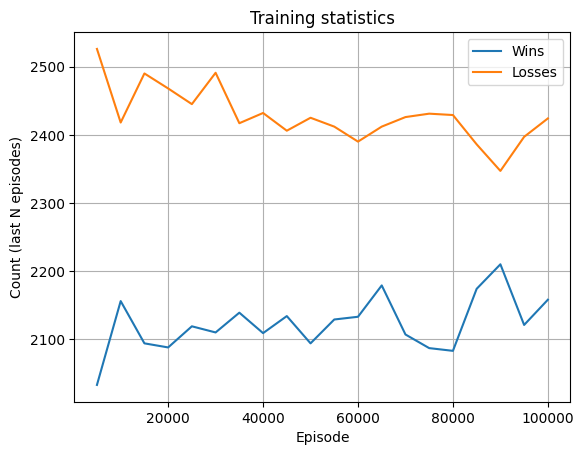

In [ ]:
import matplotlib.pyplot as plt

def plot_stats(stats):
    episodes, wins, losses = zip(*stats)
    plt.plot(episodes, wins, label='Wins')
    plt.plot(episodes, losses, label='Losses')
    plt.xlabel('Episode')
    plt.ylabel('Count (last N episodes)')
    plt.title('Training statistics')
    plt.legend()
    plt.grid(True)
    plt.show()

ep_rewards, stats = agent.train()
plot_stats(stats)


In [ ]:
def print_policy(agent):
    print("Policy (usable ace = True):")
    for player_sum in range(12, 22):
        row = ""
        for dealer_card in range(1, 11):
            action = np.argmax(agent.q_table[player_sum, dealer_card, 1])
            row += "H " if action == 1 else "S "
        print(f"{player_sum}: {row}")

    print("\nPolicy (usable ace = False):")
    for player_sum in range(12, 22):
        row = ""
        for dealer_card in range(1, 11):
            action = np.argmax(agent.q_table[player_sum, dealer_card, 0])
            row += "H " if action == 1 else "S "
        print(f"{player_sum}: {row}")


In [ ]:
print_policy(agent)

Policy (usable ace = True):
12: S H H H H H H H H H 
13: H H H H H H H H H H 
14: H H H S H H H H H H 
15: H H H H H H H H H H 
16: H H H H H H H H H H 
17: H H H H H H H H H H 
18: H S H H S H H S H H 
19: S S H S S H S S S H 
20: S H S H H S S S S S 
21: S S S S S S S S S S 

Policy (usable ace = False):
12: H H H S S S H H H H 
13: H H H S S S H H H H 
14: H H S S S S H S H H 
15: H S H S S S H S H H 
16: H S S S S S H H H S 
17: H S S S S S S S S S 
18: S S S S S S S S S S 
19: S S S S S S S S S S 
20: S S S S S S S S S S 
21: S S S S S S S S S S 


<p class="task" id="2"></p>

2\. Повторите решение предыдущей задачи, используя алгоритм $\epsilon$-greedy Q-learning. Исследуйте, как гиперпараметры и способ инициализации значений Q-функции влияют на результат.

Cтратегия для выбора действия:
1. Сгенерировать число $p$ из $U(0, 1)$;
2. Если $p < \epsilon$, то выбрать действие случайным образом;
3. В противном случае $a_{t+1}(s_t) = argmax_aQ(s_t, a)$.

Правило обновления Q-функции:
![q-learning](https://wikimedia.org/api/rest_v1/media/math/render/svg/d247db9eaad4bd343e7882ec546bf3847ebd36d8)

- [ ] Проверено на семинаре

In [ ]:
from dataclasses import dataclass

@dataclass
class Config:
    discount: float = 0.95
    lr: float = 0.005
    n_episodes: float = 100_000
    epsilon: float = 1.0
    final_epsilon: float = 0.3
    print_every: int = 5000

In [ ]:
import gymnasium as gym
import numpy as np
from tqdm import tqdm
from dataclasses import dataclass

@dataclass
class Config:
    discount: float = 0.95
    lr: float = 0.005
    n_episodes: float = 100_000
    epsilon: float = 1.0
    final_epsilon: float = 0.3
    print_every: int = 5000


class Agent:
    def __init__(self, env: gym.Env, config: Config) -> None:
        self.env = env
        self.cfg = config
        self.epsilon = config.epsilon
        self._create_q_table()

    def _create_q_table(self):
        self.q_table = np.zeros((32, 11, 2, 2))  # Q[state][action]

    def get_action(self, state: tuple) -> int:
        if np.random.rand() < self.epsilon:
            return self.env.action_space.sample()
        player, dealer, ace = state
        return int(np.argmax(self.q_table[player, dealer, int(ace)]))

    def update_q_table(self, state, new_state, reward, action, done):
        player, dealer, ace = state
        q_values = self.q_table[player, dealer, int(ace)]

        if done:
            target = reward
        else:
            new_player, new_dealer, new_ace = new_state
            target = reward + self.cfg.discount * np.max(self.q_table[new_player, new_dealer, int(new_ace)])

        q_values[action] += self.cfg.lr * (target - q_values[action])

    def run_episode(self) -> float:
        done = False
        state, _ = self.env.reset()
        while not done:
            action = self.get_action(state)
            new_state, reward, terminated, truncated, _ = self.env.step(action)
            done = terminated or truncated
            self.update_q_table(state, new_state, reward, action, done)
            state = new_state
        return reward

    def train(self):
        ep_rewards = []
        stats = []

        eps_decay = (self.cfg.epsilon - self.cfg.final_epsilon) / self.cfg.n_episodes

        for ep in tqdm(range(int(self.cfg.n_episodes))):
            reward = self.run_episode()
            ep_rewards.append(reward)

            self.epsilon = max(self.cfg.final_epsilon, self.epsilon - eps_decay)

            if (ep + 1) % self.cfg.print_every == 0:
                wins = sum(r == 1 for r in ep_rewards[-self.cfg.print_every:])
                losses = sum(r == -1 for r in ep_rewards[-self.cfg.print_every:])
                print(f"Episode {ep+1}: Wins: {wins}, Losses: {losses}, Epsilon: {self.epsilon:.3f}")
                stats.append((ep + 1, wins, losses))

        return ep_rewards, stats

    def test(self, n_games=10000):
        wins = 0
        for _ in range(n_games):
            done = False
            state, _ = self.env.reset()
            while not done:
                player, dealer, ace = state
                action = int(np.argmax(self.q_table[player, dealer, int(ace)]))  # always greedy
                new_state, reward, terminated, truncated, _ = self.env.step(action)
                done = terminated or truncated
                state = new_state
            if reward == 1:
                wins += 1
        print(f"Win rate over {n_games} games: {wins / n_games:.2f}")


In [ ]:
env = gym.make("Blackjack-v1", sab=True)
config = Config()
agent = Agent(env, config)
ep_rewards, stats = agent.train()
agent.test(10000)


  6%|▌         | 5534/100000 [00:01<00:20, 4580.73it/s]

Episode 5000: Wins: 1427, Losses: 3373, Epsilon: 0.965


 11%|█         | 10926/100000 [00:02<00:11, 7532.95it/s]

Episode 10000: Wins: 1392, Losses: 3362, Epsilon: 0.930


 16%|█▋        | 16367/100000 [00:02<00:10, 7665.84it/s]

...

Episode 90000: Wins: 1811, Losses: 2830, Epsilon: 0.370


 96%|█████████▋| 96416/100000 [00:14<00:00, 8099.74it/s]

Episode 95000: Wins: 1892, Losses: 2776, Epsilon: 0.335


100%|██████████| 100000/100000 [00:14<00:00, 6871.68it/s]


Episode 100000: Wins: 1958, Losses: 2671, Epsilon: 0.300
Win rate over 10000 games: 0.43


<p class="task" id="3"></p>

3\. Повторите решение задачи 1, используя алгоритм double Q-learning.

Cтратегия для выбора действия:
1. Сгенерировать число $p$ из $U(0, 1)$;
2. Если $p < \epsilon$, то выбрать действие случайным образом;
3. В противном случае $a_{t+1}(s_t) = argmax_a\left((Q^A_t + Q^B_t)(s_t, a))\right) $.

Правило обновления Q-функции:
$$
Q^A_{t+1}(s_{t}, a_{t}) = Q^A_{t}(s_{t}, a_{t}) + \alpha_{t}(s_{t}, a_{t}) \left(r_{t} + \gamma Q^B_{t}\left(s_{t+1}, {arg~max}_{a} Q^A_t(s_{t+1}, a)\right) - Q^A_{t}(s_{t}, a_{t})\right)
$$

$$
Q^B_{t+1}(s_{t}, a_{t}) = Q^B_{t}(s_{t}, a_{t}) + \alpha_{t}(s_{t}, a_{t}) \left(r_{t} + \gamma Q^A_{t}\left(s_{t+1}, {arg~max}_{a} Q^B_t(s_{t+1}, a)\right) - Q^B_{t}(s_{t}, a_{t})\right)
$$


- [ ] Проверено на семинаре

In [ ]:
import gymnasium as gym
import numpy as np
from tqdm import tqdm
from dataclasses import dataclass

@dataclass
class Config:
    discount: float = 0.95
    lr: float = 0.005
    n_episodes: float = 100_000
    epsilon: float = 1.0
    final_epsilon: float = 0.3
    print_every: int = 5000


class DoubleQAgent:
    def __init__(self, env: gym.Env, config: Config):
        self.env = env
        self.cfg = config
        self.epsilon = config.epsilon
        self._init_q_tables()

    def _init_q_tables(self):
        self.q_a = np.zeros((32, 11, 2, 2))
        self.q_b = np.zeros((32, 11, 2, 2))

    def get_action(self, state: tuple) -> int:
        if np.random.rand() < self.epsilon:
            return self.env.action_space.sample()
        player, dealer, ace = state
        q_sum = self.q_a[player, dealer, int(ace)] + self.q_b[player, dealer, int(ace)]
        return int(np.argmax(q_sum))

    def update_q_tables(self, state, new_state, reward, action, done):
        player, dealer, ace = state
        new_player, new_dealer, new_ace = new_state

        if np.random.rand() < 0.5:
            # Обновляем Q_A
            next_action = np.argmax(self.q_a[new_player, new_dealer, int(new_ace)])
            target = reward
            if not done:
                target += self.cfg.discount * self.q_b[new_player, new_dealer, int(new_ace)][next_action]
            self.q_a[player, dealer, int(ace)][action] += self.cfg.lr * (
                target - self.q_a[player, dealer, int(ace)][action]
            )
        else:
            # Обновляем Q_B
            next_action = np.argmax(self.q_b[new_player, new_dealer, int(new_ace)])
            target = reward
            if not done:
                target += self.cfg.discount * self.q_a[new_player, new_dealer, int(new_ace)][next_action]
            self.q_b[player, dealer, int(ace)][action] += self.cfg.lr * (
                target - self.q_b[player, dealer, int(ace)][action]
            )

    def run_episode(self) -> float:
        done = False
        state, _ = self.env.reset()
        while not done:
            action = self.get_action(state)
            new_state, reward, terminated, truncated, _ = self.env.step(action)
            done = terminated or truncated
            self.update_q_tables(state, new_state, reward, action, done)
            state = new_state
        return reward

    def train(self):
        ep_rewards = []
        stats = []
        eps_decay = (self.cfg.epsilon - self.cfg.final_epsilon) / self.cfg.n_episodes

        for ep in tqdm(range(int(self.cfg.n_episodes))):
            reward = self.run_episode()
            ep_rewards.append(reward)
            self.epsilon = max(self.cfg.final_epsilon, self.epsilon - eps_decay)

            if (ep + 1) % self.cfg.print_every == 0:
                wins = sum(r == 1 for r in ep_rewards[-self.cfg.print_every:])
                losses = sum(r == -1 for r in ep_rewards[-self.cfg.print_every:])
                print(f"Episode {ep+1}: Wins: {wins}, Losses: {losses}, Epsilon: {self.epsilon:.3f}")
                stats.append((ep + 1, wins, losses))

        return ep_rewards, stats

    def test(self, n_games=10000):
        wins = 0
        for _ in range(n_games):
            done = False
            state, _ = self.env.reset()
            while not done:
                player, dealer, ace = state
                q_sum = self.q_a[player, dealer, int(ace)] + self.q_b[player, dealer, int(ace)]
                action = int(np.argmax(q_sum))
                new_state, reward, terminated, truncated, _ = self.env.step(action)
                done = terminated or truncated
                state = new_state
            if reward == 1:
                wins += 1
        print(f"Win rate over {n_games} games: {wins / n_games:.2f}")


In [ ]:
env = gym.make("Blackjack-v1", sab=True)
config = Config()
agent = DoubleQAgent(env, config)
rewards, stats = agent.train()
agent.test(10000)


  6%|▌         | 6077/100000 [00:00<00:13, 6957.55it/s]

Episode 5000: Wins: 1438, Losses: 3377, Epsilon: 0.965


 11%|█▏        | 11366/100000 [00:01<00:11, 7469.23it/s]

Episode 10000: Wins: 1483, Losses: 3292, Epsilon: 0.930


 16%|█▌        | 16008/100000 [00:02<00:11, 7350.39it/s]

...

Episode 90000: Wins: 1877, Losses: 2777, Epsilon: 0.370


 96%|█████████▋| 96321/100000 [00:14<00:00, 7410.93it/s]

Episode 95000: Wins: 1913, Losses: 2739, Epsilon: 0.335


100%|██████████| 100000/100000 [00:14<00:00, 6850.74it/s]


Episode 100000: Wins: 1944, Losses: 2698, Epsilon: 0.300
Win rate over 10000 games: 0.43


<p class="task" id="4"></p>

4\. Обучите агента для управления машиной (окружение `MountainCar-v0`) при помощи любого из рассмотренных вариантов алгоритма Q-learning. Для перехода от непрерывного пространства состояний к конечному разбейте пространство состояний на окна (количество окон выберите сами). Для определения минимальных и максимальных значений координат воспользуйтесь [информацией об окружении](https://gymnasium.farama.org/environments/classic_control/mountain_car/#observation-space). Во время обучения несколько раз вычислите среднее значение наград за эпизод за несколько последних эпизодов и количество успешных сессий за последние эпизоды. После завершения обучения визуализируйте полученные данные.

Сделайте несколько промежуточных видео с записью работы агента во время обучения.

- [ ] Проверено на семинаре

In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
from gymnasium.wrappers import RecordVideo
from dataclasses import dataclass

@dataclass
class Config:
    n_episodes: int = 50_000
    lr: float = 0.1
    gamma: float = 0.99
    epsilon: float = 1.0
    final_epsilon: float = 0.05
    n_bins: tuple = (18, 14)  # (позиция, скорость)
    print_every: int = 5000

class QAgent:
    def __init__(self, env: gym.Env, cfg: Config):
        self.env = env
        self.cfg = cfg
        self.epsilon = cfg.epsilon
        self.obs_space_low = env.observation_space.low
        self.obs_space_high = env.observation_space.high
        self.bins = [np.linspace(self.obs_space_low[i], self.obs_space_high[i], cfg.n_bins[i] - 1)
                     for i in range(len(cfg.n_bins))]
        self.q_table = np.zeros((*cfg.n_bins, env.action_space.n))
        self.eps_decay = (cfg.epsilon - cfg.final_epsilon) / cfg.n_episodes

    def discretize(self, state):
        return tuple(
            np.digitize(state[i], self.bins[i]) for i in range(len(state))
        )

    def get_action(self, state):
        if np.random.rand() < self.epsilon:
            return self.env.action_space.sample()
        return np.argmax(self.q_table[state])

    def update(self, state, action, reward, next_state, done):
        future = 0 if done else np.max(self.q_table[next_state])
        target = reward + self.cfg.gamma * future
        self.q_table[state][action] += self.cfg.lr * (target - self.q_table[state][action])

    def run_episode(self, render=False):
        state, _ = self.env.reset()
        state = self.discretize(state)
        total_reward = 0
        done = False

        while not done:
            action = self.get_action(state)
            obs, reward, terminated, truncated, _ = self.env.step(action)
            next_state = self.discretize(obs)
            done = terminated or truncated
            self.update(state, action, reward, next_state, done)
            state = next_state
            total_reward += reward

        return total_reward, obs[0] >= 0.5

    def train(self):
        rewards = []
        successes = []
        stats = []

        for ep in tqdm(range(self.cfg.n_episodes)):
            total_reward, success = self.run_episode()
            rewards.append(total_reward)
            successes.append(int(success))

            self.epsilon = max(self.cfg.final_epsilon, self.epsilon - self.eps_decay)

            if (ep + 1) % self.cfg.print_every == 0:
                avg_reward = np.mean(rewards[-self.cfg.print_every:])
                success_count = np.sum(successes[-self.cfg.print_every:])
                print(f"Episode {ep+1}: avg_reward={avg_reward:.2f}, successes={success_count}")
                stats.append((ep + 1, avg_reward, success_count))

        return rewards, stats

    def record_video(self, path="videos", name="final", n_episodes=3):
        os.makedirs(path, exist_ok=True)
        env = RecordVideo(gym.make("MountainCar-v0", render_mode="rgb_array"), video_folder=path, name_prefix=name)
        for _ in range(n_episodes):
            state, _ = env.reset()
            state = self.discretize(state)
            done = False
            while not done:
                action = np.argmax(self.q_table[state])
                obs, _, terminated, truncated, _ = env.step(action)
                done = terminated or truncated
                state = self.discretize(obs)
        env.close()


In [ ]:
def plot_learning(stats):
    episodes, avg_rewards, success_counts = zip(*stats)
    fig, ax1 = plt.subplots()

    ax1.set_xlabel('Episode')
    ax1.set_ylabel('Average Reward', color='blue')
    ax1.plot(episodes, avg_rewards, color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')

    ax2 = ax1.twinx()
    ax2.set_ylabel('Success Count', color='green')
    ax2.plot(episodes, success_counts, color='green')
    ax2.tick_params(axis='y', labelcolor='green')

    plt.title("Training Progress")
    plt.show()


 10%|█         | 5009/50000 [01:06<09:44, 76.93it/s]

Episode 5000: avg_reward=-200.00, successes=0


 20%|██        | 10010/50000 [02:13<08:16, 80.47it/s]

Episode 10000: avg_reward=-200.00, successes=0


 30%|███       | 15012/50000 [03:19<06:39, 87.67it/s]

...

Episode 40000: avg_reward=-196.56, successes=730


 90%|█████████ | 45016/50000 [09:45<00:55, 90.48it/s]

Episode 45000: avg_reward=-188.93, successes=1862


100%|██████████| 50000/50000 [10:42<00:00, 77.79it/s]


Episode 50000: avg_reward=-181.02, successes=2655


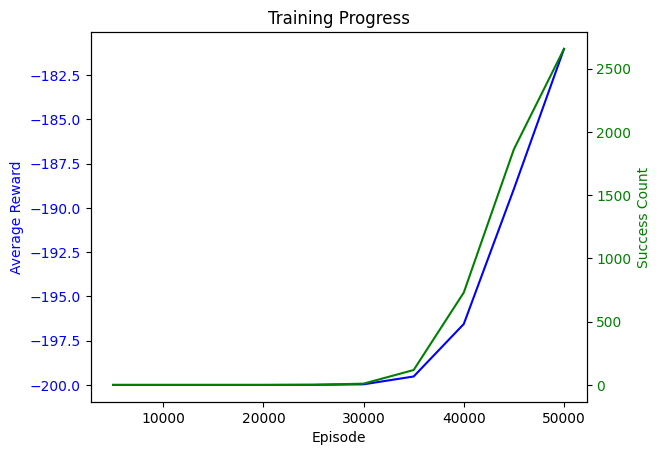

/usr/local/lib/python3.11/dist-packages/gymnasium/wrappers/rendering.py:283: UserWarning: WARN: Overwriting existing videos at /content/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [ ]:
лenv = gym.make("MountainCar-v0")
config = Config()
agent = QAgent(env, config)
rewards, stats = agent.train()

# Визуализация прогресса
plot_learning(stats)

# Видео: финальные 3 эпизода
agent.record_video(name="final_test", n_episodes=3)

# Видео: промежуточное видео после 10k эпизодов (можно делать в цикле)
# agent.record_video(name="after_10k", n_episodes=2)
